In [1]:
import matplotlib.pyplot as plt
import h5py, json, numpy as np
from scipy.optimize import minimize
from tqdm.auto import tqdm
from pathlib import Path
import pickle

##### load equidistant measurement:

In [2]:
#config:
n_baseline_margin = 2
z_ixs_used = [0]
measurements_directory = '../datasets/OB300 fixed disks/'
files = sorted([p.name for p in Path(measurements_directory).glob('*.hdf5')])

In [3]:
def load_file(file_path):
    file = h5py.File(file_path)
    s11 = file['s11_map']
    s11_z = file['s11_map'][:,:,z_ixs_used,:]
    freq_info = json.loads(file.attrs['vna_config'])
    metadata = json.loads(file.attrs['measurement_config'])
    frequencies = np.linspace(freq_info['start'], freq_info['stop'], freq_info['points'])
    
    x_pos, y_pos, z_pos = [np.linspace(metadata['space'][ax][0], metadata['space'][ax][1], s11.shape[ax])*1e-3 for ax in range(3)]
    x_plt, y_plt = np.meshgrid(x_pos, y_pos, indexing='ij')
    x_pts, y_pts = x_plt.flatten(), y_plt.flatten()
    s11_flat = np.array(s11).reshape(-1, s11.shape[2], s11.shape[3])
    s11_z_flat = np.array(s11_z).reshape(-1, s11_z.shape[2], s11_z.shape[3])

    #s11_ref = (np.mean(s11[0:2,:,:], axis=0) + np.mean(s11[0:-2,:,:], axis=0))/2
    #s11_diff = s11 - s11_ref[None,:,:,:]
    #E_field = np.sqrt(s11_diff / np.reshape(frequencies, (1,1,1,len(frequencies))))
    
    #print(s11.shape, s11_flat.shape)
    #print(s11_z.shape, s11_z_flat.shape)
    
    return s11, s11_flat, s11_z, s11_z_flat, frequencies, x_pos, x_plt, x_pts, y_pos, y_plt, y_pts, z_pos

##### plot functions:

In [4]:
def plot_point_selection(s11, frequencies, ixs, lines, x_pos, x_pts, y_pos, y_pts, z_pos, z_ix=0, f_ix=250, show_point_ix=False, show_line_ix=False):
    fig, ax = plt.subplots(figsize=(10, 5))

    # contour plot of |S11| at channel 0, frequency index 250
    cf = ax.contourf(x_pos, y_pos, np.abs(s11[:, :, z_ix, f_ix]).T, levels=20, cmap='viridis')
    fig.colorbar(cf, ax=ax, label='|S11|')

    # overlay all grid points in grey
    ax.scatter(x_pts, y_pts, s=10, c='grey', alpha=0.6, linewidths=0, label='grid points', zorder=3)

    # overlay lines y = a*x + b within plot bounds
    x_line = np.linspace(x_pos.min(), x_pos.max(), 400)
    for i, (a, b) in enumerate(lines):
        y_line = a * x_line + b
        mask = (y_line >= y_pos.min()) & (y_line <= y_pos.max())
        ax.plot(x_line[mask], y_line[mask], color='orange', linewidth=1, zorder=5, label='selection lines' if i == 0 else None)

        if show_line_ix and np.any(mask):
            # place label below the line near the middle of the visible segment
            x_seg = x_line[mask]
            y_seg = y_line[mask]
            mid = len(x_seg) // 2
            line_label_offset = 5.0  # in data units
            ax.text(x_seg[mid], y_seg[mid] - line_label_offset, f'Line {i}',
                    ha='center', va='top', fontsize=8, color='orange', zorder=6, clip_on=True)

    if show_point_ix:
        # handle indices or boolean mask
        ixs_arr = np.asarray(ixs)
        sel_idx = np.flatnonzero(ixs_arr) if ixs_arr.dtype == bool else ixs_arr.astype(int)
        # put index labels below each selected point
        y_offset = 2.0  # in data units
        for idx in sel_idx:
            ax.text(x_pts[idx], y_pts[idx] - y_offset, str(idx), ha='center', va='top', fontsize=7, color='red', zorder=6, clip_on=True)

    # overlay selected points in red
    ax.scatter(x_pts[ixs], y_pts[ixs], s=20, c='red', alpha=0.9, linewidths=0, label='selected points', zorder=4)

    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(f'|S11| at z={z_pos[z_ix]} mm, $\\nu$={frequencies[f_ix]*1e-9:.2f} GHz\nwith grid, selection lines and selected points')
    ax.legend(loc='upper left')

In [5]:
def plot_sqrt_Dgamma_line(
    lines,
    idxs_sorted_lines,
    s_sorted_lines,
    baseline_lines,
    sqrt_Dgamma_lines,
    line_index,
    n_baseline_margin,
    s11_flat,
    z_pos,
    frequencies,
    z_ix=0,
    f_ix=250,
):
    """
    Plot precomputed sqrt_Dgamma_lines[i] along the parametric line coordinate s for a given z_ix and f_ix.
    Highlights the first and last n_baseline_margin points used for baseline fitting,
    and overlays the precomputed linearly fitted baseline (on |S11|) for reference.

    Args:
        lines (list[tuple]): list of (a, b) for each line y = a*x + b.
        idxs_sorted_lines (list[np.ndarray]): list of sorted point indices per line.
        s_sorted_lines (list[np.ndarray]): list of sorted parametric coordinates s per line.
        baseline_lines (list[np.ndarray]): list of baseline arrays per line, shape (M, z, f).
        sqrt_Dgamma_lines (list[np.ndarray]): list of sqrt(DeltaGamma) per line, shape (M, z, f).
        line_index (int): index of the line to plot.
        n_baseline_margin (int): number of points at each end used for baseline fitting (for highlighting).
        z_ix (int): z index to plot.
        f_ix (int): frequency index to plot.
    """
    # sanity checks
    if not (0 <= line_index < len(lines)):
        raise ValueError(f"Line index i={line_index} out of range (0..{len(lines)-1}).")
    if z_ix < 0 or z_ix >= s11_flat.shape[1]:
        raise ValueError(f"z_ix out of range (0..{s11_flat.shape[1]-1}).")
    if f_ix < 0 or f_ix >= s11_flat.shape[2]:
        raise ValueError(f"f_ix out of range (0..{s11_flat.shape[2]-1}).")

    if (
        idxs_sorted_lines[line_index] is None
        or s_sorted_lines[line_index] is None
        or baseline_lines[line_index] is None
        or sqrt_Dgamma_lines[line_index] is None
    ):
        raise ValueError("Precomputed data for this line is missing (idxs/s/baseline/sqrt_Dgamma).")

    # precomputed per-line data
    idxs_sorted = idxs_sorted_lines[line_index]
    s_sorted = s_sorted_lines[line_index]
    baseline = baseline_lines[line_index][:, z_ix, f_ix]  # (M,)
    sqrt_dg = sqrt_Dgamma_lines[line_index][:, z_ix, f_ix]  # (M,)

    m_points = idxs_sorted.size
    if s_sorted.size != m_points or baseline.size != m_points or sqrt_dg.size != m_points:
        raise ValueError("Size mismatch among precomputed arrays for this line.")

    # baseline margin for highlighting
    n = min(n_baseline_margin, m_points // 2)
    if n == 0:
        raise ValueError("Baseline margin results in empty baseline set.")
    base_idx = np.r_[np.arange(n), np.arange(m_points - n, m_points)]

    # data along the line (complex S11) for selected (z,f)
    y_line = s11_flat[idxs_sorted, z_ix, f_ix]  # (M,)

    # parametric direction (for label only)
    a, b = lines[line_index]
    u = np.array([1.0, a], dtype=float)
    u /= np.linalg.norm(u)

    # plot
    fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    # top: |S11| with baseline
    ax0.plot(s_sorted, np.abs(y_line), 'o', ms=4, alpha=0.7, label='|$\\Gamma$| (points)')
    ax0.plot(s_sorted, np.abs(baseline), '-', lw=2, color='tab:orange', label='|baseline| (fit)')
    ax0.plot(s_sorted[base_idx], np.abs(y_line[base_idx]), 'o', ms=6, color='red', label='baseline points')

    ax0.set_ylabel('|$\\Gamma$|')
    ax0.legend(loc='best')
    ax0.set_title(f'Line {line_index}: $y={a:.3f}x + {b:.3f}$ [mm], z={z_pos[z_ix]} mm, $\\nu$={frequencies[f_ix]*1e-9:.2f} GHz')
    ax0.grid()

    # bottom: sqrt(DeltaGamma)
    ax1.plot(s_sorted, sqrt_dg, 'o-', ms=4, label='$\\sqrt{\\Delta\\Gamma}$')
    ax1.plot(s_sorted[base_idx], sqrt_dg[base_idx], 'o', ms=6, color='red', label='baseline points')
    ax1.set_xlabel(f'$s={u[0]:.3f}x + {u[1]:.3f}y$ (line parameterization)')
    ax1.set_ylabel('$\\sqrt{\\Delta\\Gamma} \\propto E$')
    ax1.legend(loc='best')
    ax1.grid()

    plt.tight_layout()
    return fig, (ax0, ax1)

In [6]:
def plot_fitted_efield(params, x_plt, y_plt, x_reduced, y_reduced, fit_data, sqrt_dgamma_full, beam_model, z_pos, frequencies, costs=None, z_ix=0, f_ix=250, overlay_points=True):
    """
    Figure 1: (left) Fitted E-field, (right) Full E-field.
    Figure 2: Relative residual map in percent: 100 * (full - fitted) / full.
    """
    # extract parameters
    p = params[z_ix, f_ix]
    x0, y0, A, s = p[:4]
    w = p[4:] if p.size > 4 else (1.0, 0.0, 0.0, 0.0)

    # evaluate model on grid
    Zm = beam_model(x_plt, y_plt, x0, y0, A, s, *w)

    # full-field slice from all grid points
    full_slice = sqrt_dgamma_full[:, :, z_ix, f_ix]

    # shared color scaling for fitted/full panels
    vals = [Zm.ravel(), full_slice.ravel()]
    overlay_vals = None
    if overlay_points and fit_data is not None:
        overlay_vals = fit_data[:, z_ix, f_ix]
        vals.append(np.asarray(overlay_vals).ravel())
    all_vals = np.concatenate(vals)
    vmin = np.nanpercentile(all_vals, 5)
    vmax = np.nanpercentile(all_vals, 95)
    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin == vmax:
        vmin, vmax = np.nanmin(all_vals), np.nanmax(all_vals)

    # residuals
    residual = full_slice - Zm
    denom = np.where(np.abs(full_slice) > np.finfo(float).eps, full_slice, np.nan)
    rel_residual = 100.0 * residual / denom
    rmaxp = np.nanpercentile(np.abs(rel_residual), 95)
    if not np.isfinite(rmaxp) or rmaxp == 0:
        rmaxp = np.nanmax(np.abs(rel_residual))

    # Figure 1: two panels (fitted, full) with a dedicated colorbar axis of the same height
    fig_top = plt.figure(figsize=(14, 6), constrained_layout=True)
    gs = fig_top.add_gridspec(nrows=1, ncols=3, width_ratios=[1.5, 1.5, 0.06], wspace=0.05)
    ax0 = fig_top.add_subplot(gs[0, 0])
    ax1 = fig_top.add_subplot(gs[0, 1])
    cax = fig_top.add_subplot(gs[0, 2])

    # Panel 1: Fitted
    ax0.contourf(x_plt, y_plt, Zm, levels=30, cmap='viridis', vmin=vmin, vmax=vmax)
    if overlay_points and x_reduced is not None and y_reduced is not None and fit_data is not None:
        ax0.scatter(x_reduced, y_reduced, c=overlay_vals, cmap='viridis', vmin=vmin, vmax=vmax,
                    s=25, edgecolors='k', linewidths=0.2, alpha=0.9, label='data')
        ax0.legend(loc='upper right')
    title0 = f'Fitted E-field at z={z_pos[z_ix]} mm, ν={frequencies[f_ix]*1e-9:.2f} GHz'
    if costs is not None:
        title0 += f', MSE cost={float(costs[z_ix, f_ix]):.3e}'
    ax0.set_title(title0)

    # Panel 2: Full field
    cf1 = ax1.contourf(x_plt, y_plt, full_slice, levels=30, cmap='viridis', vmin=vmin, vmax=vmax)
    ax1.set_title('Full E-field (all points)')

    # Colorbar with same height as the panels
    fig_top.colorbar(cf1, cax=cax, label='E-field (shared scale)')

    for ax in (ax0, ax1):
        ax.set_xlabel('x [mm]')
        ax.set_ylabel('y [mm]')
        ax.set_aspect('equal', adjustable='box')
        ax.grid(True, alpha=0.2)

    # Figure 2: residual only
    fig_res = plt.figure(figsize=(10, 5), constrained_layout=True)
    axr = fig_res.add_subplot(111)
    cfr = axr.contourf(x_plt, y_plt, rel_residual, levels=30, cmap='coolwarm', vmin=-rmaxp, vmax=rmaxp)
    fig_res.colorbar(cfr, ax=axr, label='Residual (% of full)')
    axr.set_title('Residual (full - fitted) [%]')
    axr.set_xlabel('x [mm]')
    axr.set_ylabel('y [mm]')
    axr.set_aspect('equal', adjustable='box')
    axr.grid(True, alpha=0.2)

    return fig_top, (ax0, ax1), fig_res, axr


In [7]:
def plot_beta_overlay(beta_reduced, beta_full, frequencies, colors=('tab:blue', 'tab:red')):
    """
    Plot beta_reduced and beta_full on the same panel with a shared x-axis (frequency),
    but separate y-axes. Make curves more distinguishable via line style, width, markers, and alpha.
    """
    freq_ghz = np.asarray(frequencies) * 1e-9

    # sparse markers to avoid clutter even if curves overlap
    N = freq_ghz.size
    step = max(1, N // 40)

    fig, ax_left = plt.subplots(figsize=(9, 4))
    l1 = ax_left.plot(
        freq_ghz, beta_reduced,
        color=colors[0], lw=1.0, linestyle='--',
        marker='o', ms=3, markevery=step,
        alpha=0.9, zorder=3, label='β from reduced BP'
    )
    ax_left.set_xlim(19, 20)
    ax_left.set_xlabel('Frequency (GHz)')
    ax_left.set_ylabel('β (a.u.)')
    ax_left.tick_params(axis='y')
    ax_left.grid(True, which='both', alpha=0.3)

    l2 = ax_left.plot(
        freq_ghz, beta_full,
        color=colors[1], lw=1.0, linestyle='-',
        marker='s', ms=3, markevery=(step // 2, step),
        alpha=0.9, zorder=2, label='β from full BP'
    )
    # distinct dash pattern for the right line
    l2[0].set_dashes((6, 2))

    lines = l1 + l2
    labels = [line.get_label() for line in lines]
    ax_left.legend(lines, labels, loc='upper right')

    plt.tight_layout()
    #return fig, ax_left


##### full $\sqrt{\Delta\Gamma}$ calculation:

In [8]:
def compute_sqrt_Dgamma_full(s11, x_pos, y_pos, z_pos, n_baseline_margin):
    Nx, Ny, Nz, Nf = s11.shape
    n = min(int(n_baseline_margin), Nx // 2)
    if n <= 0:
        raise ValueError("n_baseline_margin must be >= 1 and less than half the number of x points.")

    # indices of baseline points along each y-row (first n and last n x positions)
    baseline_ix = np.r_[np.arange(n), np.arange(Nx - n, Nx)]
    m = baseline_ix.size

    # precompute x sums for least-squares
    s_base = x_pos[baseline_ix]                 # (m,)
    sum_s = s_base.sum()
    sum_s2 = (s_base ** 2).sum()
    den = m * sum_s2 - sum_s ** 2

    sqrt_dgamma_full = np.empty(s11.shape, dtype=np.float64)

    for j in range(Ny):  # iterate over y-rows
        # gather baseline samples for all (z,f) on this y-row
        y_base = s11[baseline_ix, j, :, :]      # (m, Nz, Nf)

        # least-squares fit of complex baseline: y ≈ beta0 + beta1 * x
        sum_y = y_base.sum(axis=0)                              # (Nz, Nf)
        sum_sy = (s_base[:, None, None] * y_base).sum(axis=0)   # (Nz, Nf)

        if den == 0:
            beta0 = y_base.mean(axis=0)
            beta1 = np.zeros_like(beta0)
        else:
            beta0 = (sum_s2 * sum_y - sum_s * sum_sy) / den
            beta1 = (m * sum_sy - sum_s * sum_y) / den

        # evaluate baseline for all x along this y-row
        base_row = beta0[None, :, :] + beta1[None, :, :] * x_pos[:, None, None]   # (Nx, Nz, Nf)

        # DeltaGamma = s11 - baseline, then sqrt(abs(.))
        dgamma_row = s11[:, j, :, :] - base_row
        sqrt_dgamma_full[:, j, :, :] = np.sqrt(np.abs(dgamma_row))

    return sqrt_dgamma_full

##### full $E_T$ calculation:

In [9]:
def sqrt_dgamma_to_E(sqrt_dgamma, frequencies):
    # scale sqrt_dgamma to E-field units using the same convention as the Julia snippet
    eps_b = 9.23
    delta_eps = eps_b - 1.0
    r_b = (2.93e-3) / 2.0
    V_b = 4.0 / 3.0 * np.pi * r_b ** 3
    alpha_0 = 3.0 * delta_eps * V_b / (eps_b + 2.0)

    P_in = 1.0
    epsilon0 = 8.85418782e-12

    nu_hz = np.asarray(frequencies, dtype=float).ravel()
    conv = np.sqrt(4.0 * P_in / (epsilon0 * alpha_0 * 1j * 2.0 * np.pi * nu_hz))
    conv_shape = (1,) * (sqrt_dgamma.ndim - 1) + (conv.size,)
    return sqrt_dgamma * conv.reshape(conv_shape)

In [10]:
def compute_ET_full(sqrt_dgamma_full, x_pos, y_pos, frequencies):
    ET_full = sqrt_dgamma_to_E(sqrt_dgamma_full, frequencies)
    return np.nansum(ET_full, axis=(0, 1)) * np.mean(np.diff(x_pos)) * np.mean(np.diff(y_pos))

##### Reduced Point Cloud Calculation:

In [11]:
def reduce_points_to_lines(s11_z_flat, x_pts, y_pts):
    def points_near_lines(lines, tol=2):
        lines = np.asarray(lines, dtype=float)
        a = lines[:, 0]
        b = lines[:, 1]
        residuals = np.abs(y_pts[:, None] - (x_pts[:, None] * a[None, :] + b[None, :]))
        per_line_masks = (residuals <= tol)
        any_mask = per_line_masks.any(axis=1)
        return any_mask, per_line_masks.T

    lines = [
        (.15, 80*1e-3),
        (-.15, 40*1e-3),
        (.15, 0),
        (-.15, -40*1e-3)
    ]
    all_ixs, per_line_ixs = points_near_lines(lines, tol=3*1e-3)
    s11_reduced = s11_z_flat[all_ixs, :, :]
    x_reduced = x_pts[all_ixs]
    y_reduced = y_pts[all_ixs]
    
    return s11_reduced, x_reduced, y_reduced, lines, all_ixs, per_line_ixs

##### $\sqrt{\Delta\Gamma}$ reduced calculation:

In [12]:
def compute_sqrt_Dgamma_lines(s11_z_flat, x_pts, y_pts, lines, per_line_ixs, all_ixs, n_baseline_margin):
    # linear baseline subtraction per line using least-squares fit along the tilted line direction
    #sqrt_Dgamma = np.full_like(s11_flat, np.nan + 1j * np.nan)
    sqrt_Dgamma = np.empty(s11_z_flat.shape, dtype=np.float64)
    sqrt_Dgamma_lines = [None] * len(lines)

    # store precomputed per-line arrays for plotting
    baseline_lines = [None] * len(lines)
    s_sorted_lines = [None] * len(lines)
    idxs_sorted_lines = [None] * len(lines)

    for line_index, (a, b) in enumerate(lines):
        mask = per_line_ixs[line_index]
        idxs = np.flatnonzero(mask)
        if idxs.size < 2:
            continue

        # parametric coordinate s along the line direction (accounts for tilt)
        u = np.array([1.0, a], dtype=float)
        u /= np.linalg.norm(u)  # normalize direction vector
        s_all = u[0] * x_pts[idxs] + u[1] * y_pts[idxs]

        # order points along the line by s
        order = np.argsort(s_all)
        idxs_sorted = idxs[order]
        s_all_sorted = s_all[order]
        m_points = idxs_sorted.size

        # take first and last n points as baseline set
        n = min(n_baseline_margin, m_points // 2)
        if n == 0:
            continue

        s_base = np.concatenate([s_all_sorted[:n], s_all_sorted[-n:]])
        y_base = s11_z_flat[np.concatenate([idxs_sorted[:n], idxs_sorted[-n:]]), :, :]  # (M,z,f)

        # least-squares fit y ≈ beta0 + beta1 * s for each (z,f)
        m = s_base.size
        sum_s = s_base.sum()
        sum_s2 = (s_base ** 2).sum()
        sum_y = y_base.sum(axis=0)  # (z,f)
        sum_sy = (s_base[:, None, None] * y_base).sum(axis=0)  # (z,f)

        den = m * sum_s2 - sum_s ** 2
        if den == 0:
            beta0 = y_base.mean(axis=0)
            beta1 = np.zeros_like(beta0)
        else:
            beta0 = (sum_s2 * sum_y - sum_s * sum_sy) / den
            beta1 = (m * sum_sy - sum_s * sum_y) / den

        # evaluate baseline for all points on the line using s_all_sorted
        base = beta0[None, :, :] + beta1[None, :, :] * s_all_sorted[:, None, None]  # (M,z,f)

        # subtract to obtain delta_gamma
        sqrt_Dgamma_line = np.sqrt(np.abs(s11_z_flat[idxs_sorted, :, :] - base))
        sqrt_Dgamma[idxs_sorted, :, :] = sqrt_Dgamma_line
        sqrt_Dgamma_lines[line_index] = sqrt_Dgamma_line

        # store for plotting
        baseline_lines[line_index] = base
        s_sorted_lines[line_index] = s_all_sorted
        idxs_sorted_lines[line_index] = idxs_sorted

    # convenience: delta_gamma for the reduced point cloud
    sqrt_Dgamma_reduced = sqrt_Dgamma[all_ixs]
    return sqrt_Dgamma_reduced, sqrt_Dgamma_lines, baseline_lines, s_sorted_lines, idxs_sorted_lines

##### E-field fit:

In [13]:
hermite_0 = lambda _, __ : 1
hermite_1 = lambda x, s : 4*x/s**2
hermite_2 = lambda x, s : 4*(4*x**2-s**2)/s**4
h_polyn = [hermite_0, hermite_1, hermite_2]

def beam_model(x, y, x0, y0, A, s, *weights):
    DEGREE = 1
    value1 = A * np.exp(-((x-x0)**2+(y-y0)**2)/s**2)
    value2 = np.zeros(x.shape)
    i, j = 0, 0
    vec = np.vectorize
    weights /= np.sum(weights)
    for weight in weights:
        j_ = j % (DEGREE+1)
        value2 += vec(h_polyn[i])(x-x0, s) * vec(h_polyn[j_])(y-y0,s) * weight
        if j_ == DEGREE: i += 1
        j += 1
    return value1*value2

In [14]:
class BeamFit(object):
    def __init__(self, sqrt_Dgamma_reduced, frequencies, x_reduced, y_reduced,):
        self.sqrt_Dgamma_reduced = sqrt_Dgamma_reduced
        self.frequencies = frequencies
        self.x_reduced = x_reduced
        self.y_reduced = y_reduced

    def cost(self, fit_param, z_ix, f_ix):
        #x0, y0, A, s, w0, w1, w2, w3 = fit_param
        x0, y0, A, s = fit_param
        w0, w1, w2, w3 = 1.0, 0.0, 0.0, 0.0
        model_output = beam_model(self.x_reduced, self.y_reduced, x0, y0, A, s, w0, w1, w2, w3)
        data = self.sqrt_Dgamma_reduced[:, z_ix, f_ix]
        return np.nanmean((data - model_output)**2)

    def fit_slice(self, start, z_ix, f_ix, disp=False):
        res = minimize(self.cost, start, method='nelder-mead', args=(z_ix, f_ix), options={'disp': False})
        if disp:
            print(f'z={z_ix}, f={f_ix}, fit={res.x}, cost={res.fun}, success={res.success}')
        return res

    def fit_all(self, start=None, disp=False):
        if start is None:
            start = np.array([0.0, 0.0, 0.01, .05, 1.0, 1.0, 1.0, 1.0], dtype=float)
            start = np.array([0.0, 0.0, 0.01, .05], dtype=float)
        Z = self.sqrt_Dgamma_reduced.shape[1]
        F = self.sqrt_Dgamma_reduced.shape[2]
        self.params = np.full((Z, F, start.size), np.nan)
        self.costs = np.full((Z, F), np.nan)
        self.success = np.zeros((Z, F), dtype=bool)
        progress_bar = tqdm(total=Z*F, desc='E-field fit', unit='fit')
        for z in range(Z):
            for f in range(F):
                res = minimize(self.cost, start, method='nelder-mead', args=(z, f), options={'disp': False})
                self.params[z, f, :] = res.x
                self.costs[z, f] = res.fun
                self.success[z, f] = res.success
                progress_bar.set_postfix(z=z, f=f, cost=float(res.fun))
                progress_bar.update(1)
            if disp:
                tqdm.write(f'z={z}, f={self.frequencies[250]*1e-9:.2f} GHz, fit={self.params[z, 250, :]}, cost={res.fun}, success={res.success}')
        progress_bar.close()
        return self.params, self.costs, self.success

In [15]:
import multiprocessing as mp
import os
import sys
from concurrent.futures import ThreadPoolExecutor, as_completed

_beamfit_worker_state = {}

def _beamfit_worker_init(sqrt_dgamma_reduced, x_reduced, y_reduced):
    global _beamfit_worker_state
    _beamfit_worker_state = {
        'sqrt_dgamma_reduced': sqrt_dgamma_reduced,
        'x_reduced': x_reduced,
        'y_reduced': y_reduced,
    }

def _beamfit_worker_task(task):
    z_ix, f_ix, start = task
    sqrt_dgamma_reduced = _beamfit_worker_state['sqrt_dgamma_reduced']
    x_reduced = _beamfit_worker_state['x_reduced']
    y_reduced = _beamfit_worker_state['y_reduced']

    def _cost(fit_param):
        x0, y0, A, s = fit_param
        w0, w1, w2, w3 = 1.0, 0.0, 0.0, 0.0
        model_output = beam_model(x_reduced, y_reduced, x0, y0, A, s, w0, w1, w2, w3)
        data = sqrt_dgamma_reduced[:, z_ix, f_ix]
        return np.nanmean((data - model_output) ** 2)

    res = minimize(_cost, start, method='nelder-mead', options={'disp': False})
    return z_ix, f_ix, res.x, float(res.fun), bool(res.success)

class BeamFit(object):
    def __init__(self, sqrt_Dgamma_reduced, frequencies, x_reduced, y_reduced):
        self.sqrt_Dgamma_reduced = sqrt_Dgamma_reduced
        self.frequencies = frequencies
        self.x_reduced = x_reduced
        self.y_reduced = y_reduced

    def cost(self, fit_param, z_ix, f_ix):
        x0, y0, A, s = fit_param
        w0, w1, w2, w3 = 1.0, 0.0, 0.0, 0.0
        model_output = beam_model(self.x_reduced, self.y_reduced, x0, y0, A, s, w0, w1, w2, w3)
        data = self.sqrt_Dgamma_reduced[:, z_ix, f_ix]
        return np.nanmean((data - model_output) ** 2)

    def fit_slice(self, start, z_ix, f_ix, disp=False):
        res = minimize(self.cost, start, method='nelder-mead', args=(z_ix, f_ix), options={'disp': False})
        if disp:
            print(f'z={z_ix}, f={f_ix}, fit={res.x}, cost={res.fun}, success={res.success}')
        return res

    def fit_all(self, start=None, disp=False, n_workers=None, backend=None):
        if start is None:
            start = np.array([0.0, 0.0, 0.01, 0.05], dtype=float)
        else:
            start = np.asarray(start, dtype=float)

        Z = self.sqrt_Dgamma_reduced.shape[1]
        F = self.sqrt_Dgamma_reduced.shape[2]
        self.params = np.full((Z, F, start.size), np.nan)
        self.costs = np.full((Z, F), np.nan)
        self.success = np.zeros((Z, F), dtype=bool)

        n_tasks = Z * F
        if n_workers is None:
            n_workers = max(1, mp.cpu_count() - 1)
        n_workers = int(max(1, min(n_workers, n_tasks)))

        if backend is None:
            # In Windows notebooks, multiprocessing 'spawn' often has high startup/serialization overhead.
            backend = 'thread' if (os.name == 'nt' and 'ipykernel' in sys.modules) else 'process'
        if backend not in ('thread', 'process', 'sequential'):
            raise ValueError("backend must be one of {'thread', 'process', 'sequential'}")

        progress_bar = tqdm(total=n_tasks, desc='E-field fit', unit='fit')

        try:
            if backend == 'thread':
                with ThreadPoolExecutor(max_workers=n_workers) as executor:
                    futures = {
                        executor.submit(self.fit_slice, start, z, f, False): (z, f)
                        for z in range(Z)
                        for f in range(F)
                    }
                    for future in as_completed(futures):
                        z, f = futures[future]
                        res = future.result()
                        self.params[z, f, :] = res.x
                        self.costs[z, f] = res.fun
                        self.success[z, f] = res.success
                        progress_bar.set_postfix(z=z, f=f, cost=float(res.fun))
                        progress_bar.update(1)

            elif backend == 'process':
                tasks = [(z, f, start) for z in range(Z) for f in range(F)]
                with mp.get_context('spawn').Pool(
                    processes=n_workers,
                    initializer=_beamfit_worker_init,
                    initargs=(self.sqrt_Dgamma_reduced, self.x_reduced, self.y_reduced),
                ) as pool:
                    chunksize = max(1, n_tasks // (n_workers * 4))
                    for z, f, p, c, ok in pool.imap_unordered(_beamfit_worker_task, tasks, chunksize=chunksize):
                        self.params[z, f, :] = p
                        self.costs[z, f] = c
                        self.success[z, f] = ok
                        progress_bar.set_postfix(z=z, f=f, cost=float(c))
                        progress_bar.update(1)

            else:
                for z in range(Z):
                    for f in range(F):
                        res = minimize(self.cost, start, method='nelder-mead', args=(z, f), options={'disp': False})
                        self.params[z, f, :] = res.x
                        self.costs[z, f] = res.fun
                        self.success[z, f] = res.success
                        progress_bar.set_postfix(z=z, f=f, cost=float(res.fun))
                        progress_bar.update(1)

        except Exception as exc:
            if disp:
                tqdm.write(f'Parallel backend unavailable ({exc}); falling back to sequential fitting.')
            for z in range(Z):
                for f in range(F):
                    res = minimize(self.cost, start, method='nelder-mead', args=(z, f), options={'disp': False})
                    self.params[z, f, :] = res.x
                    self.costs[z, f] = res.fun
                    self.success[z, f] = res.success
                    progress_bar.set_postfix(z=z, f=f, cost=float(res.fun))
                    progress_bar.update(1)

        progress_bar.close()

        if disp and F > 250:
            for z in range(Z):
                tqdm.write(
                    f"z={z}, f={self.frequencies[250]*1e-9:.2f} GHz, "
                    f"fit={self.params[z, 250, :]}, cost={self.costs[z, 250]}, success={self.success[z, 250]}"
                )

        return self.params, self.costs, self.success

##### reduced $E_T$ calculation:

In [16]:
def compute_ET_reduced(params, x_pos, y_pos, beam_model, frequencies):
    """
    Compute transverse E-field ET for each z-slice and frequency using a fresh n1 x n2
    integration grid over (x,y). Unlike beta_reduced, this does NOT integrate over z.

    Returns:
        ET_reduced: array of shape (Z, Nf) with ∫∫ E(x,y; z,f) dx dy per (z,f).
    """
    n1 = 50
    n2 = 50

    # new integration axes and mesh
    x_lin = np.linspace(np.min(x_pos), np.max(x_pos), n1)
    y_lin = np.linspace(np.min(y_pos), np.max(y_pos), n2)
    X, Y = np.meshgrid(x_lin, y_lin, indexing='ij')

    Z, Nf = params.shape[0], params.shape[1]
    ET_reduced = np.full((Z, Nf), np.nan, dtype=np.float64)

    for f_ix in range(Nf):
        for z_ix in range(Z):
            p = params[z_ix, f_ix, :4]
            if not np.all(np.isfinite(p)):
                continue
            x0, y0, A, s = map(float, p)

            # evaluate beam model on the fresh grid
            E_field = beam_model(X, Y, x0, y0, A, s, 1.0, 0.0, 0.0, 0.0)

            # 2D trapezoidal integration over the new grid (y, then x)
            ET_reduced[z_ix, f_ix] = np.trapezoid(np.trapezoid(E_field, y_lin, axis=1), x_lin, axis=0)
    
    
    ET_reduced = sqrt_dgamma_to_E(ET_reduced, frequencies)
    return ET_reduced

##### Execution:

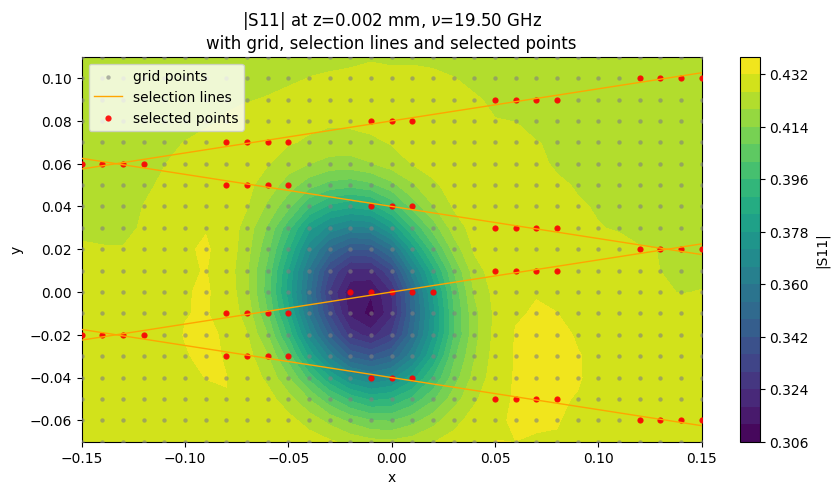

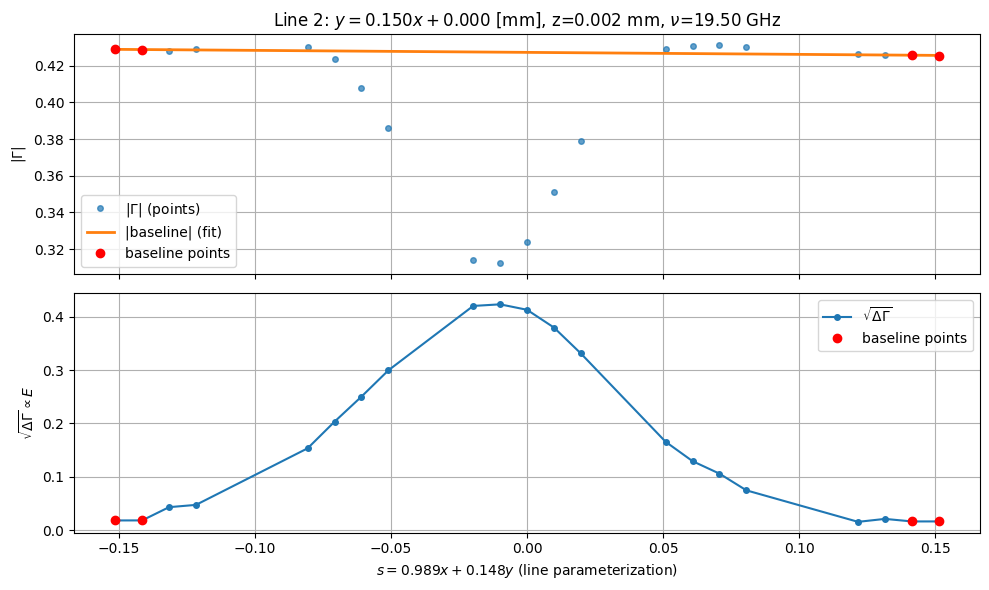

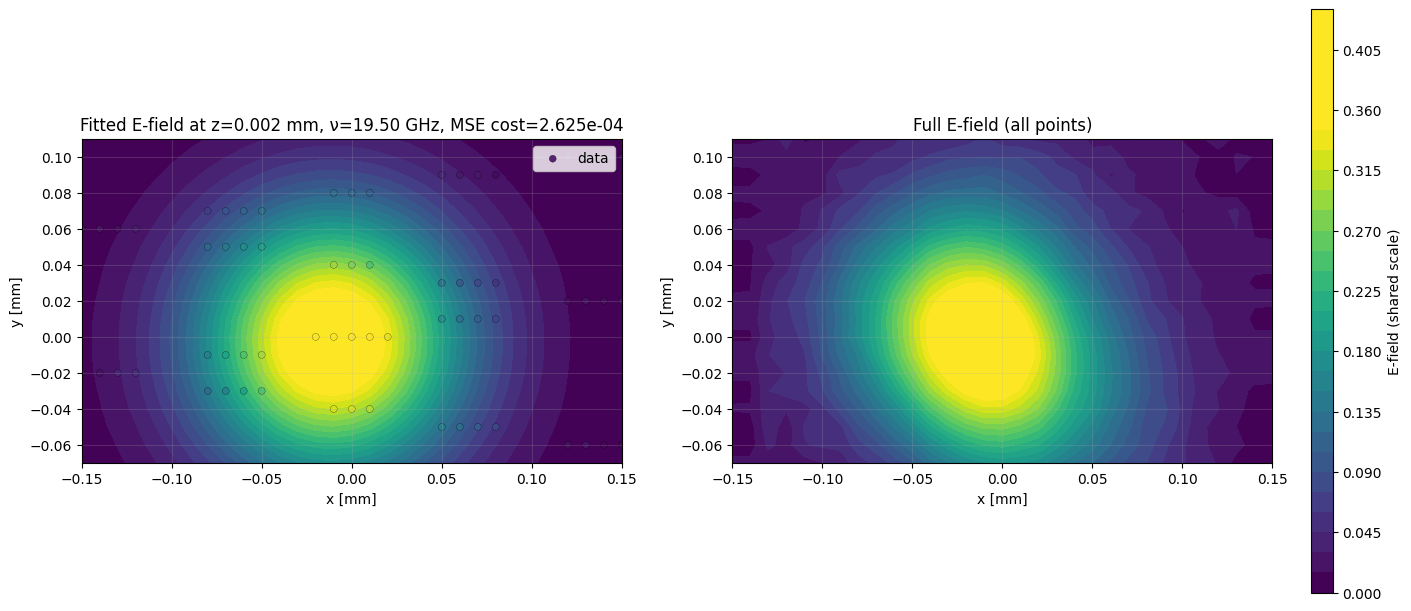

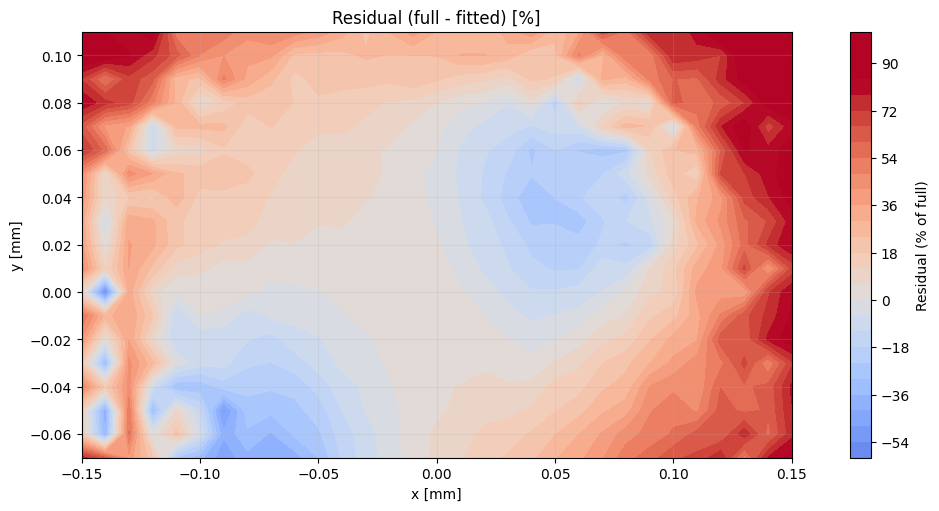

In [17]:
plot_ix = 0
existing_fit_file = None
data_folder = "./data/"
existing_fit_file = data_folder + 'beam_fit_results_all_z_m.pkl'

if existing_fit_file is None:
    fit_results_per_file = []
else:
    with open(existing_fit_file, 'rb') as file:
        fit_results_per_file = pickle.load(file)['all_fits']    

ETs_reduced, ETs_full = [], []
z_reduced, z_full = [], []

for i, file in enumerate(files):
    s11, s11_flat, s11_z, s11_z_flat, frequencies, x_pos, x_plt, x_pts, y_pos, y_plt, y_pts, z_pos = load_file(measurements_directory + file)
    s11_reduced, x_reduced, y_reduced, lines, all_ixs, per_line_ixs = reduce_points_to_lines(s11_z_flat, x_pts, y_pts)
    sqrt_Dgamma_reduced, sqrt_Dgamma_lines, baseline_lines, s_sorted_lines, idxs_sorted_lines = compute_sqrt_Dgamma_lines(s11_z_flat, x_pts, y_pts, lines, per_line_ixs, all_ixs, n_baseline_margin)

    if existing_fit_file is None:
        beam_fit = BeamFit(sqrt_Dgamma_reduced, frequencies, x_reduced, y_reduced)
        beam_fit.fit_all()
        
        fit_results_per_file += [{
            'params': beam_fit.params,
            'costs': beam_fit.costs,
            'success': beam_fit.success,
        }]
        fit_params = beam_fit.params
        fit_costs = beam_fit.costs
    else:
        fit_params = fit_results_per_file[i]['params']
        fit_costs = fit_results_per_file[i]['costs']
    
    ETs_reduced += list(compute_ET_reduced(fit_params, x_pos, y_pos, beam_model, frequencies))
    z_reduced += list(z_pos[z_ixs_used])
    
    sqrt_dgamma_full = compute_sqrt_Dgamma_full(s11, x_pos, y_pos, z_pos, n_baseline_margin)
    ETs_full += list(compute_ET_full(sqrt_dgamma_full, x_pos, y_pos, frequencies))
    z_full += list(z_pos)
    
    if i == plot_ix:
        plot_point_selection(s11, frequencies, all_ixs, lines, x_pos, x_pts, y_pos, y_pts, z_pos, z_ix=z_ixs_used[0], f_ix=250, show_point_ix=False, show_line_ix=True)
        plot_sqrt_Dgamma_line(lines, idxs_sorted_lines, s_sorted_lines, baseline_lines, sqrt_Dgamma_lines, line_index=2, n_baseline_margin=n_baseline_margin, s11_flat=s11_z_flat, z_pos=z_pos, frequencies=frequencies, z_ix=0, f_ix=250)
        plot_fitted_efield(fit_params, x_plt, y_plt, x_reduced, y_reduced, sqrt_Dgamma_reduced, sqrt_dgamma_full, beam_model, z_pos, frequencies, costs=fit_costs, z_ix=0, f_ix=250, overlay_points=True)

ETs_reduced = np.asarray(ETs_reduced)
ETs_full = np.asarray(ETs_full)
z_reduced = np.asarray(z_reduced).flatten()
z_full = np.asarray(z_full).flatten()

if existing_fit_file is None:
    outfile_all = data_folder + 'beam_fit_results_all_z_m.pkl'
    with open(outfile_all, 'wb') as file:
        pickle.dump({
            'all_fits': fit_results_per_file,
            'frequencies': frequencies
        }, file)
        
np.savez(data_folder + 'ET_results.npz', ETs_reduced=ETs_reduced, ETs_full=ETs_full, z_reduced=z_reduced, z_full=z_full, frequencies=frequencies)

#beta_full = np.square(np.nansum(sqrt_dgamma_full, axis=(0, 1, 2)) * np.mean(np.diff(x_pos)) * np.mean(np.diff(y_pos)) * np.mean(np.diff(z_pos)))   
#beta_full, sqrt_dgamma_full = compute_beta_full(s11, x_pos, y_pos, z_pos, n_baseline_margin)
#beta_reduced = compute_beta_reduced(params, x_pos, y_pos, z_pos, beam_model)
#plot_beta_overlay(beta_reduced, beta_full)